# RSSM Extended Evaluation


1. **Full KL time-series** across all test weeks (test1 + test2), plotted with event annotations — replaces the 4-row Table 3 with an actual figure
2. **Residual correlation comparison** across test1 (COVID) and test2 (GME) — currently only test2 is reported
3. **RSSM forecasting Spearman ρ** at horizons 1, 4, 13 weeks — direct comparison with Table 2 baselines



In [2]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "duckdb"])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.2/14.2 MB 26.4 MB/s  0:00:00 eta 0:00:01


0

## Setup

In [4]:
from __future__ import annotations

import json
import sys
import warnings
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yaml

warnings.filterwarnings("ignore", category=UserWarning)

# ── project root ──────────────────────────────────────────────────────────────
PROJECT_ROOT = Path("/Users/narayanipemmaraju/Documents/MSDS/Spring 2026/ML/Project/Repo/StockTwit_WM")
assert PROJECT_ROOT.exists(), f"Project root not found: {PROJECT_ROOT}"
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from data.vocab import Vocabulary
from data.dataset import FEATURE_COLS
from model.twit_wave import ModelConfig, TwitWave
from model.rssm import kl_divergence
from scipy.stats import spearmanr

# ── paths ─────────────────────────────────────────────────────────────────────
MODEL_DIR      = PROJECT_ROOT / "external_models" / "twitwave-rssm-large"
DATA_DIR       = PROJECT_ROOT / "data" / "processed_week"
OUT_DIR        = PROJECT_ROOT / "outputs" / "eval" / "extended_eval"
OUT_DIR.mkdir(parents=True, exist_ok=True)

CONFIG_PATH    = MODEL_DIR / "config.yaml"
NORM_STATS_PATH= MODEL_DIR / "norm_stats.json"
CHECKPOINT_PATH= MODEL_DIR / "checkpoints" / "best.pt"
EMBEDDINGS_DIR = MODEL_DIR / "embeddings"
# Current (line in 4_c):
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Replace with:
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"DEVICE       = {DEVICE}")
print(f"torch        = {torch.__version__}")

PROJECT_ROOT = /Users/narayanipemmaraju/Documents/MSDS/Spring 2026/ML/Project/Repo/StockTwit_WM
DEVICE       = mps
torch        = 2.9.0


In [6]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "huggingface_hub"])

from huggingface_hub import snapshot_download
snapshot_download(
    repo_id="abhi0710/twitwave-rssm-large",
    repo_type="model",
    local_dir="/Users/narayanipemmaraju/Documents/MSDS/Spring 2026/ML/Project/Repo/StockTwit_WM/external_models/twitwave-rssm-large",
    allow_patterns=["config.yaml", "norm_stats.json", "checkpoints/best.pt", "embeddings/*"],
)
print("Done!")

  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 661.5/661.5 kB 16.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 26.6 MB/s  0:00:00
Using cached annotated_doc-0.0.4-py3-none-any.whl (5.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [huggingface_hub] [huggingface_hub]


Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

Done!


## Load Model and Data
*(Identical to `4_b` — copy-pasted so this notebook is self-contained)*

In [7]:
# ── load artifacts ────────────────────────────────────────────────────────────
cfg        = yaml.safe_load(CONFIG_PATH.read_text(encoding="utf-8"))
model_cfg  = cfg["model"]
eval_cfg   = cfg.get("eval", {})
norm_stats = {k: np.asarray(v, dtype=np.float32)
              for k, v in json.loads(NORM_STATS_PATH.read_text()).items()}
e_dec      = np.load(EMBEDDINGS_DIR / "e_dec.npy")

ckpt       = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=False)
state_dict = ckpt.get("model_state") or ckpt.get("model_state_dict") or ckpt.get("state_dict")

# ── compatibility loader (mirrors 4_b) ────────────────────────────────────────
def normalize_state_dict_keys(sd: dict) -> dict:
    replacements = {
        "rssm.posterior_net.3.": "rssm.posterior_net.2.",
        "rssm.posterior_net.6.": "rssm.posterior_net.4.",
        "rssm.prior_net.3.":     "rssm.prior_net.2.",
        "rssm.prior_net.6.":     "rssm.prior_net.4.",
    }
    out = {}
    for k, v in sd.items():
        nk = k.removeprefix("module.")
        for old, new in replacements.items():
            if nk.startswith(old):
                nk = new + nk[len(old):]
                break
        out[nk] = v
    return out

cleaned   = normalize_state_dict_keys(state_dict)
vocab_size= int(e_dec.shape[0])
s_dim     = int(model_cfg["s_dim"])
gru_w     = cleaned.get("rssm.gru.weight_ih")
extra_dim = max(0, int(gru_w.shape[1]) - s_dim) if gru_w is not None else 0

tw_cfg = ModelConfig(
    vocab_size=vocab_size,
    embed_dim =int(model_cfg.get("embed_dim", e_dec.shape[1])),
    d_enc     =int(model_cfg["d_enc"]),
    h_dim     =int(model_cfg["h_dim"]),
    s_dim     =s_dim,
    n_heads   =int(model_cfg["n_heads"]),
    n_layers  =int(model_cfg["n_layers"]),
    window_k  =int(model_cfg["window_k"]),
    mlp_hidden=int(model_cfg["mlp_hidden"]),
    feature_dim=int(model_cfg["feature_dim"]),
    top_k     =int(model_cfg["top_k"]),
    dropout   =0.0,
    gru_input_extra_dim=extra_dim,
)

model = TwitWave(tw_cfg)
result = model.load_state_dict(cleaned, strict=False)
MODEL_READY = (len(result.missing_keys) == 0 and len(result.unexpected_keys) == 0)
model.to(DEVICE).eval()

print(f"missing keys  : {result.missing_keys}")
print(f"unexpected keys: {result.unexpected_keys}")
print(f"MODEL_READY   = {MODEL_READY}")
if not MODEL_READY:
    print("WARNING: checkpoint mismatch — results may be unreliable.")

missing keys  : []
unexpected keys: []
MODEL_READY   = True


In [8]:
# ── vocabulary and panels ─────────────────────────────────────────────────────
vocab = Vocabulary.load(DATA_DIR / "vocab.json")
FEATURE_NAMES = list(FEATURE_COLS)
CONTEXT_LEN   = int(eval_cfg.get("context_len", 52))
TOP_K         = tw_cfg.top_k

panels = {}
for split in ["train", "val", "test1", "test2"]:
    path = DATA_DIR / f"panel_{split}.parquet"
    if path.exists():
        panel = pd.read_parquet(path)
        panel["week"] = pd.to_datetime(panel["week"])
        panels[split] = panel.sort_values(["week", "symbol"]).reset_index(drop=True)
        print(f"{split:6}: rows={len(panel):7}, weeks={panel['week'].nunique():3}, "
              f"range={panel['week'].min().date()} → {panel['week'].max().date()}")

# Combined panel for context warm-up (we always need history before a test week)
all_panels = pd.concat(list(panels.values()), ignore_index=True)
all_panels = all_panels.sort_values(["week", "symbol"]).reset_index(drop=True)

[vocab] loaded 1520 tickers from /Users/narayanipemmaraju/Documents/MSDS/Spring 2026/ML/Project/Repo/StockTwit_WM/data/processed_week/vocab.json
train : rows= 109737, weeks=554, range=2008-05-26 → 2018-12-31
val   : rows=  10400, weeks= 52, range=2019-01-07 → 2019-12-30
test1 : rows=   5200, weeks= 26, range=2020-01-06 → 2020-06-29
test2 : rows=   7800, weeks= 39, range=2020-10-05 → 2021-06-28


In [9]:
# ── shared helper functions ───────────────────────────────────────────────────

def build_week_tensors(
    panel: pd.DataFrame,
    weeks: list[pd.Timestamp],
    top_k: int,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """Return (features, ids, presence) tensors for a list of weeks."""
    grouped = {pd.Timestamp(w): g for w, g in panel.groupby("week")}
    feat_list, ids_list, pres_list = [], [], []
    for week in weeks:
        grp  = grouped.get(pd.Timestamp(week))
        feat = np.zeros((top_k, len(FEATURE_NAMES)), dtype=np.float32)
        ids  = np.zeros(top_k, dtype=np.int64)
        pres = np.zeros(vocab.size, dtype=np.float32)
        if grp is not None and len(grp) > 0:
            grp = grp.sort_values("log_attention", ascending=False).head(top_k)
            vals = grp[FEATURE_NAMES].to_numpy(np.float32)
            vals = (vals - norm_stats["mean"]) / norm_stats["std"]
            n = len(grp)
            feat[:n] = vals
            ids[:n]  = [vocab.encode(s) for s in grp["symbol"].tolist()]
            pres[ids[:n]] = 1.0
        feat_list.append(feat)
        ids_list.append(ids)
        pres_list.append(pres)
    return (
        torch.tensor(np.stack(feat_list)),
        torch.tensor(np.stack(ids_list)),
        torch.tensor(np.stack(pres_list)),
    )


def context_to_week(
    panel_all: pd.DataFrame,
    week: str | pd.Timestamp,
    context_len: int,
) -> tuple[list[pd.Timestamp], torch.Tensor, torch.Tensor]:
    """Return the context window ending at `week`."""
    week  = pd.Timestamp(week)
    weeks = sorted(panel_all.loc[panel_all["week"] <= week, "week"].unique())[-context_len:]
    feat, ids, _ = build_week_tensors(panel_all, weeks, TOP_K)
    return weeks, feat, ids


def get_kl_for_week(
    model: TwitWave,
    panel_all: pd.DataFrame,
    week: str | pd.Timestamp,
    context_len: int,
) -> float:
    """Compute posterior-prior KL for a single week."""
    _, feat, ids = context_to_week(panel_all, week, context_len)
    feat = feat.to(DEVICE)
    ids  = ids.to(DEVICE)
    h, s = model.rssm.init_state(1, DEVICE)
    a_cache: list[torch.Tensor] = []
    kl_val = 0.0
    with torch.no_grad():
        for t in range(feat.shape[0]):
            a_t, _ = model._encode_step(feat[t].unsqueeze(0), ids[t].unsqueeze(0))
            a_cache.append(a_t)
            window = model._build_window(a_cache, model.cfg.window_k, DEVICE)
            e_t    = model.temporal_enc(window)
            h      = model.rssm.gru_step(h, s)
            s, post_mean, post_logvar = model.rssm.posterior(h, e_t)
            _, prior_mean, prior_logvar = model.rssm.prior(h)
            kl_val = float(kl_divergence(post_mean, post_logvar, prior_mean, prior_logvar).item())
    return kl_val   # KL of the last (target) week


print("Helpers defined.")

Helpers defined.


---
## Analysis 1 — Full KL Time Series (test1 + test2)

Instead of checking 4 hand-picked event dates, we compute KL for **every week in the held-out test periods** and plot them as a time series with event annotations.

This directly addresses the weakness in Table 3: we can now see whether COVID/GME weeks are local maxima, flat, or even local minima relative to surrounding weeks.

In [10]:
if not MODEL_READY:
    print("SKIP: model not ready.")
else:
    test_weeks = sorted(
        panels["test1"]["week"].unique().tolist() +
        panels["test2"]["week"].unique().tolist()
    )
    print(f"Computing KL for {len(test_weeks)} test weeks ...")

    kl_values = []
    for i, week in enumerate(test_weeks):
        kl = get_kl_for_week(model, all_panels, week, CONTEXT_LEN)
        kl_values.append(kl)
        if (i + 1) % 10 == 0:
            print(f"  {i+1}/{len(test_weeks)} — week {pd.Timestamp(week).date()}, KL={kl:.3f}")

    kl_df = pd.DataFrame({"week": test_weeks, "kl": kl_values})
    kl_df["week"] = pd.to_datetime(kl_df["week"])
    kl_df["split"] = kl_df["week"].apply(
        lambda w: "test1 (COVID)" if w <= pd.Timestamp("2020-06-30") else "test2 (GME)"
    )
    kl_df.to_csv(OUT_DIR / "kl_full_test_series.csv", index=False)
    print(f"\nSaved → {OUT_DIR / 'kl_full_test_series.csv'}")
    print(kl_df.describe())

Computing KL for 65 test weeks ...
  10/65 — week 2020-03-09, KL=52.775
  20/65 — week 2020-05-18, KL=56.767
  30/65 — week 2020-10-26, KL=53.493
  40/65 — week 2021-01-04, KL=56.203
  50/65 — week 2021-03-15, KL=52.345
  60/65 — week 2021-05-24, KL=51.038

Saved → /Users/narayanipemmaraju/Documents/MSDS/Spring 2026/ML/Project/Repo/StockTwit_WM/outputs/eval/extended_eval/kl_full_test_series.csv
                      week         kl
count                   65  65.000000
mean   2020-10-10 14:24:00  53.660416
min    2020-01-06 00:00:00  49.118469
25%    2020-04-27 00:00:00  52.577644
50%    2020-11-16 00:00:00  53.713112
75%    2021-03-08 00:00:00  54.482594
max    2021-06-28 00:00:00  59.985596
std                    NaN   1.957908


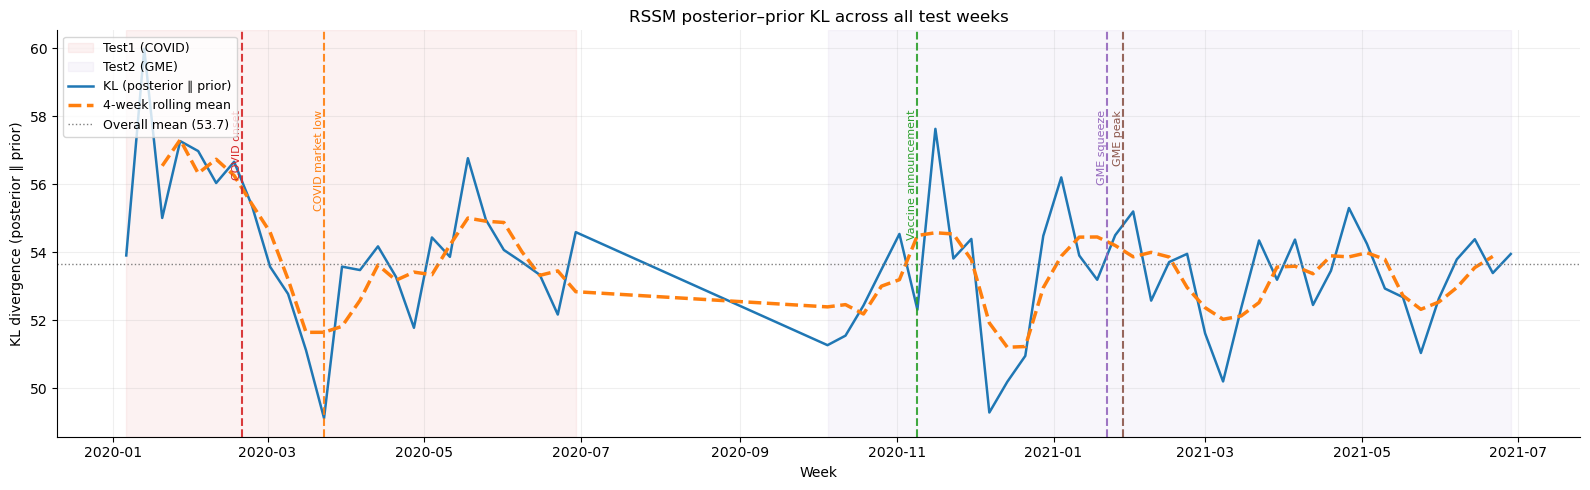

Saved → /Users/narayanipemmaraju/Documents/MSDS/Spring 2026/ML/Project/Repo/StockTwit_WM/outputs/eval/extended_eval/kl_full_test_timeline.png


In [11]:
if not MODEL_READY:
    print("SKIP")
else:
    KNOWN_EVENTS = [
        {"date": "2020-02-20", "label": "COVID onset",           "color": "#D62728"},
        {"date": "2020-03-23", "label": "COVID market low",      "color": "#FF7F0E"},
        {"date": "2020-11-09", "label": "Vaccine announcement",  "color": "#2CA02C"},
        {"date": "2021-01-22", "label": "GME squeeze",           "color": "#9467BD"},
        {"date": "2021-01-28", "label": "GME peak",              "color": "#8C564B"},
    ]

    fig, ax = plt.subplots(figsize=(16, 5))

    # Shade test periods
    t1_weeks = kl_df[kl_df["split"] == "test1 (COVID)"]
    t2_weeks = kl_df[kl_df["split"] == "test2 (GME)"]
    ax.axvspan(t1_weeks["week"].min(), t1_weeks["week"].max(), alpha=0.06, color="#D62728", label="Test1 (COVID)")
    ax.axvspan(t2_weeks["week"].min(), t2_weeks["week"].max(), alpha=0.06, color="#9467BD", label="Test2 (GME)")

    ax.plot(kl_df["week"], kl_df["kl"], lw=1.8, color="#1f77b4", label="KL (posterior ∥ prior)")

    # Rolling mean
    ax.plot(kl_df["week"], kl_df["kl"].rolling(4, center=True).mean(),
            lw=2.5, color="#ff7f0e", linestyle="--", label="4-week rolling mean")

    # Global mean line
    ax.axhline(kl_df["kl"].mean(), color="gray", lw=1, linestyle=":", label=f"Overall mean ({kl_df['kl'].mean():.1f})")

    # Event annotations
    ymax = kl_df["kl"].max()
    for ev in KNOWN_EVENTS:
        ev_date = pd.Timestamp(ev["date"])
        if kl_df["week"].min() <= ev_date <= kl_df["week"].max():
            ax.axvline(ev_date, color=ev["color"], lw=1.5, linestyle="--", alpha=0.9)
            ax.text(ev_date, ymax * 0.97, ev["label"],
                    rotation=90, va="top", ha="right", fontsize=8, color=ev["color"])

    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.set_xlabel("Week")
    ax.set_ylabel("KL divergence (posterior ∥ prior)")
    ax.set_title("RSSM posterior–prior KL across all test weeks")
    ax.legend(loc="upper left", fontsize=9)
    ax.grid(alpha=0.2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "kl_full_test_timeline.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {OUT_DIR / 'kl_full_test_timeline.png'}")

In [12]:
# Summary stats: is KL higher/lower in event weeks vs surrounding weeks?
if not MODEL_READY:
    print("SKIP")
else:
    event_dates = {pd.Timestamp(e["date"]) for e in KNOWN_EVENTS}

    # Find nearest week in our data for each event
    results = []
    for ev in KNOWN_EVENTS:
        ev_date = pd.Timestamp(ev["date"])
        if kl_df["week"].min() > ev_date or kl_df["week"].max() < ev_date:
            continue
        # nearest week
        nearest_idx = (kl_df["week"] - ev_date).abs().idxmin()
        event_kl    = kl_df.loc[nearest_idx, "kl"]
        # ±4 week window (excluding event itself)
        window_mask = (
            (kl_df["week"] >= ev_date - pd.Timedelta(weeks=4)) &
            (kl_df["week"] <= ev_date + pd.Timedelta(weeks=4)) &
            (kl_df.index != nearest_idx)
        )
        window_kl   = kl_df.loc[window_mask, "kl"]
        results.append({
            "event":        ev["label"],
            "event_week":   kl_df.loc[nearest_idx, "week"].date(),
            "event_kl":     round(event_kl, 3),
            "window_mean":  round(window_kl.mean(), 3),
            "window_std":   round(window_kl.std(), 3),
            "z_score":      round((event_kl - window_kl.mean()) / (window_kl.std() + 1e-8), 3),
        })

    summary_df = pd.DataFrame(results)
    summary_df.to_csv(OUT_DIR / "kl_event_summary.csv", index=False)
    print("KL event summary (window = ±4 weeks, test-period only):")
    print(summary_df.to_string(index=False))

KL event summary (window = ±4 weeks, test-period only):
               event event_week  event_kl  window_mean  window_std  z_score
         COVID onset 2020-02-17    56.663       54.729       2.304    0.839
    COVID market low 2020-03-23    49.118       53.416       1.202   -3.575
Vaccine announcement 2020-11-09    52.312       53.393       2.439   -0.443
         GME squeeze 2021-01-25    54.502       54.182       1.229    0.260
            GME peak 2021-01-25    54.502       54.107       1.224    0.323


---
## Analysis 2 — Residual Correlation: test1 (COVID) vs test2 (GME)

The original notebook computes residual correlation only on test2.  
Here we run it on **both splits** and compare the mean absolute off-diagonal values.

In [13]:
if not MODEL_READY:
    print("SKIP")
else:
    residual_summary = {}

    for split in ["test1", "test2"]:
        if split not in panels:
            print(f"{split}: not found, skipping.")
            continue

        weeks = sorted(panels[split]["week"].unique())
        print(f"\n{split}: computing residuals for {len(weeks)} weeks ...")

        residual_rows = []
        with torch.no_grad():
            for week in weeks:
                _, feat, ids = context_to_week(all_panels, week, CONTEXT_LEN)
                feat = feat.to(DEVICE)
                ids  = ids.to(DEVICE)
                h, s = model.context_phase(feat, ids)
                h_new, s_new, z, logits = model.forward_step_prior(h, s, use_mean=True)

                # Ground truth presence
                true_week = panels[split][panels[split]["week"] == week]
                y = np.zeros(vocab.size, dtype=np.float32)
                y[[vocab.encode(sym) for sym in true_week["symbol"].tolist()]] = 1.0

                probs = torch.sigmoid(logits[0]).cpu().numpy()
                residual_rows.append(y - probs)

        residuals = np.stack(residual_rows)   # (T, vocab_size)

        # Select 50 most active tickers
        active = np.where(np.abs(residuals).sum(axis=0) > 0)[0][:50]
        corr   = np.corrcoef(residuals[:, active].T)
        offdiag_mean = float(np.abs(corr[~np.eye(corr.shape[0], dtype=bool)]).mean())

        residual_summary[split] = {
            "weeks":           len(weeks),
            "active_tickers":  len(active),
            "mean_abs_offdiag": round(offdiag_mean, 4),
        }

        # Save correlation matrix
        labels = [vocab.decode(int(i)) for i in active]
        pd.DataFrame(corr, index=labels, columns=labels).to_csv(
            OUT_DIR / f"residual_corr_{split}.csv"
        )
        print(f"  {split}: mean_abs_offdiag_residual_corr = {offdiag_mean:.4f}")

    print("\n── Residual Correlation Comparison ──")
    for split, stats in residual_summary.items():
        label = "COVID" if split == "test1" else "GME"
        print(f"  {split} ({label:5}): weeks={stats['weeks']:2}, "
              f"tickers={stats['active_tickers']:2}, "
              f"mean |offdiag corr| = {stats['mean_abs_offdiag']}")


test1: computing residuals for 26 weeks ...
  test1: mean_abs_offdiag_residual_corr = 0.6508

test2: computing residuals for 39 weeks ...
  test2: mean_abs_offdiag_residual_corr = 0.5274

── Residual Correlation Comparison ──
  test1 (COVID): weeks=26, tickers=50, mean |offdiag corr| = 0.6508
  test2 (GME  ): weeks=39, tickers=50, mean |offdiag corr| = 0.5274


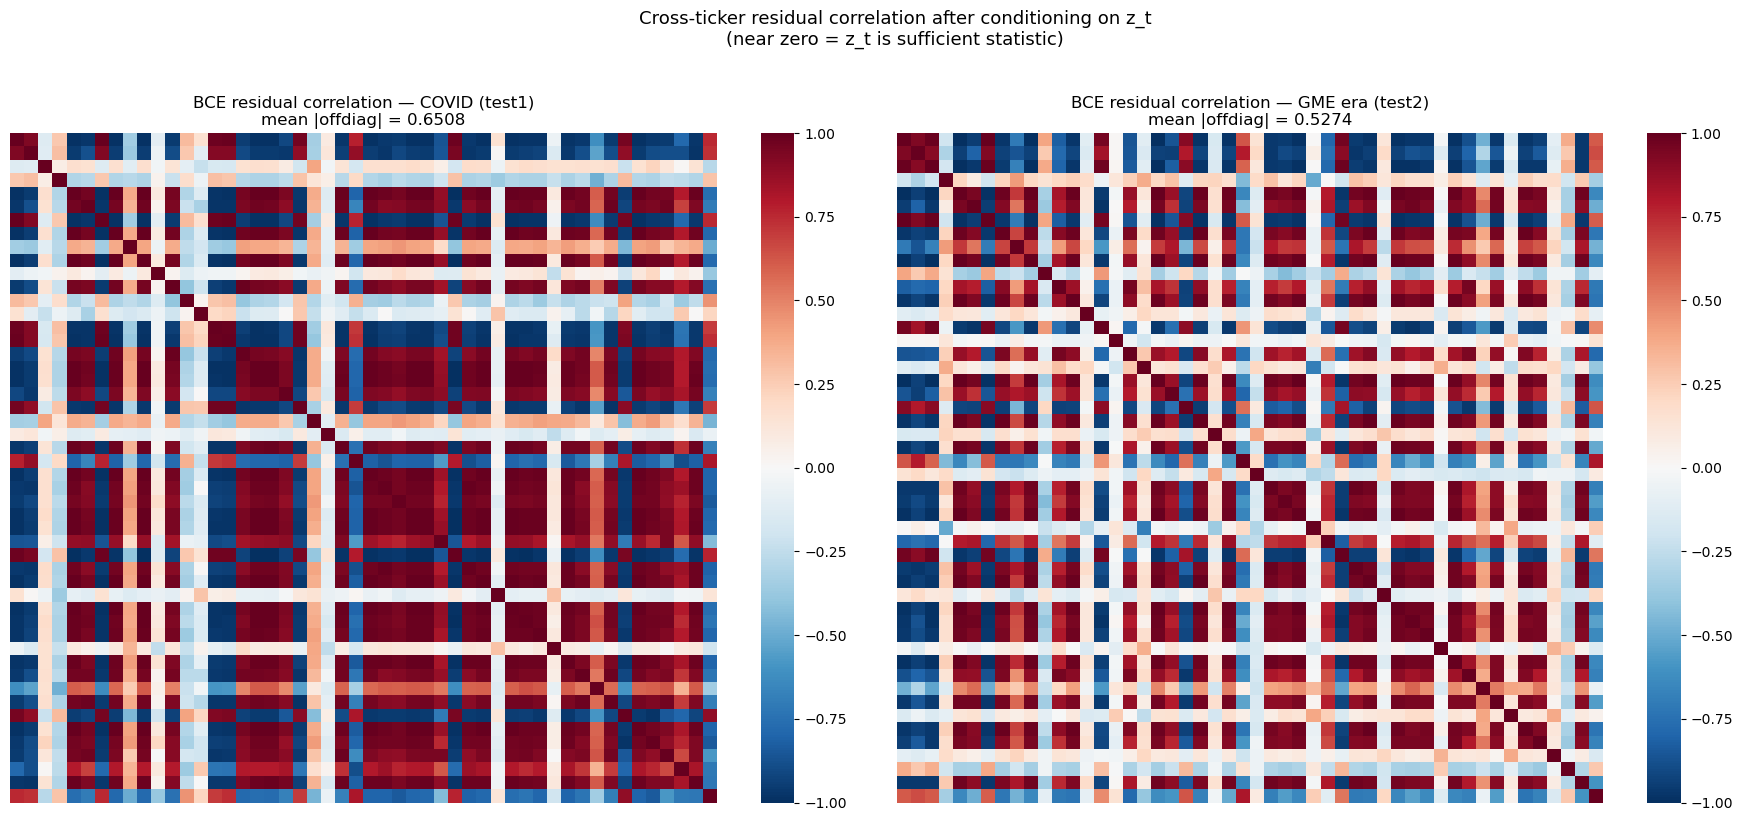

Saved → /Users/narayanipemmaraju/Documents/MSDS/Spring 2026/ML/Project/Repo/StockTwit_WM/outputs/eval/extended_eval/residual_corr_comparison.png


In [14]:
# Side-by-side heatmaps
if not MODEL_READY:
    print("SKIP")
else:
    import seaborn as sns

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    for ax, split in zip(axes, ["test1", "test2"]):
        csv_path = OUT_DIR / f"residual_corr_{split}.csv"
        if not csv_path.exists():
            ax.set_title(f"{split}: not computed")
            continue
        corr_df = pd.read_csv(csv_path, index_col=0)
        label   = "COVID (test1)" if split == "test1" else "GME era (test2)"
        sns.heatmap(
            corr_df, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            xticklabels=False, yticklabels=False, ax=ax, cbar=True,
        )
        ax.set_title(f"BCE residual correlation — {label}\n"
                     f"mean |offdiag| = {residual_summary[split]['mean_abs_offdiag']}")

    plt.suptitle("Cross-ticker residual correlation after conditioning on z_t\n"
                 "(near zero = z_t is sufficient statistic)", y=1.02, fontsize=13)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "residual_corr_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {OUT_DIR / 'residual_corr_comparison.png'}")

---
## Analysis 3 — RSSM Forecasting: Spearman ρ at horizons 1, 4, 13 weeks

This is the **missing comparison** from the paper.  
We roll the RSSM prior forward and compute Spearman ρ on log_attention rankings,  
exactly matching the metric used for ARIMA/VAR/LSTM in Table 2.

For each test week:
1. Build context window ending the week **before** the target
2. Roll prior forward h steps
3. Decode log_attention for all vocab tickers
4. Compute Spearman ρ against realized log_attention

In [15]:
if not MODEL_READY:
    print("SKIP")
else:
    HORIZONS  = [1, 4, 13]
    LOG_ATTN_IDX = FEATURE_NAMES.index("log_attention")
    ALL_IDS   = torch.arange(vocab.size, dtype=torch.long).unsqueeze(0).to(DEVICE)  # (1, V)

    def rssm_spearman_for_split(split: str) -> dict:
        """Compute Spearman rho at each horizon for one test split."""
        test_panel = panels[split]
        test_weeks = sorted(test_panel["week"].unique())

        results = {h: [] for h in HORIZONS}

        for i, target_week in enumerate(test_weeks):
            # Context ends the week BEFORE the target
            ctx_weeks_all = sorted(all_panels.loc[all_panels["week"] < target_week, "week"].unique())
            if len(ctx_weeks_all) < 1:
                continue

            # Ground-truth log_attention for ALL vocab tickers at each horizon
            for h_steps in HORIZONS:
                # Target week is `h_steps` ahead — find it in the test panel
                future_idx = i + h_steps - 1   # 0-indexed within test_weeks
                if future_idx >= len(test_weeks):
                    continue
                future_week = test_weeks[future_idx]
                future_data = test_panel[test_panel["week"] == future_week]

                # Build true log_attention vector over all vocab tickers
                true_la = np.zeros(vocab.size, dtype=np.float32)
                for _, row in future_data.iterrows():
                    if vocab.has(row["symbol"]):
                        true_la[vocab.encode(row["symbol"])] = float(row["log_attention"])

                if true_la.std() < 1e-6:
                    continue

                # Context tensor
                ctx_weeks = ctx_weeks_all[-CONTEXT_LEN:]
                feat, ids, _ = build_week_tensors(all_panels, ctx_weeks, TOP_K)
                feat = feat.to(DEVICE)
                ids  = ids.to(DEVICE)

                with torch.no_grad():
                    h_state, s_state = model.context_phase(feat, ids)
                    # Roll prior forward h_steps
                    for _ in range(h_steps):
                        h_state, s_state, z, _ = model.forward_step_prior(
                            h_state, s_state, use_mean=True
                        )
                    # Decode log_attention for all tickers
                    pred_feats = model.decode_features(z, ALL_IDS)[0].cpu().numpy()  # (V, 5)
                    pred_la    = pred_feats[:, LOG_ATTN_IDX]   # (V,)

                rho, _ = spearmanr(pred_la, true_la)
                if not np.isnan(rho):
                    results[h_steps].append(rho)

        return {h: float(np.mean(v)) if v else float("nan") for h, v in results.items()}

    spearman_results = {}
    for split in ["test1", "test2"]:
        if split not in panels:
            continue
        label = "COVID (2020 Q1-Q2)" if split == "test1" else "GME era (2021)"
        print(f"\nComputing RSSM Spearman ρ for {split} ({label}) ...")
        rhos = rssm_spearman_for_split(split)
        spearman_results[split] = rhos
        for h, rho in rhos.items():
            print(f"  horizon {h:2}w: Spearman ρ = {rho:.3f}")

    # Save
    rows = []
    for split, rhos in spearman_results.items():
        for h, rho in rhos.items():
            rows.append({"split": split, "horizon_weeks": h, "spearman_rho": rho})
    pd.DataFrame(rows).to_csv(OUT_DIR / "rssm_spearman.csv", index=False)
    print(f"\nSaved → {OUT_DIR / 'rssm_spearman.csv'}")


Computing RSSM Spearman ρ for test1 (COVID (2020 Q1-Q2)) ...
  horizon  1w: Spearman ρ = 0.131
  horizon  4w: Spearman ρ = 0.128
  horizon 13w: Spearman ρ = 0.115

Computing RSSM Spearman ρ for test2 (GME era (2021)) ...
  horizon  1w: Spearman ρ = 0.091
  horizon  4w: Spearman ρ = 0.091
  horizon 13w: Spearman ρ = 0.086

Saved → /Users/narayanipemmaraju/Documents/MSDS/Spring 2026/ML/Project/Repo/StockTwit_WM/outputs/eval/extended_eval/rssm_spearman.csv


In [16]:
# Print comparison table matching Table 2 format from the paper
if not MODEL_READY:
    print("SKIP")
else:
    # Baseline results from Table 2 in the paper
    baselines = [
        {"split": "test1", "model": "ARIMA", 1: 0.596, 4: 0.537, 13: 0.427},
        {"split": "test1", "model": "VAR",   1: -0.025, 4: 0.103, 13: -0.062},
        {"split": "test1", "model": "LSTM",  1: 0.514, 4: 0.538, 13: 0.554},
        {"split": "test2", "model": "ARIMA", 1: 0.446, 4: 0.461, 13: 0.348},
        {"split": "test2", "model": "VAR",   1: -0.046, 4: -0.141, 13: -0.039},
        {"split": "test2", "model": "LSTM",  1: 0.325, 4: 0.481,  13: 0.419},
    ]

    # Add RSSM rows
    for split in ["test1", "test2"]:
        if split in spearman_results:
            rhos = spearman_results[split]
            baselines.append({
                "split": split, "model": "RSSM (ours)",
                1: rhos.get(1, float("nan")),
                4: rhos.get(4, float("nan")),
                13: rhos.get(13, float("nan")),
            })

    comparison_df = pd.DataFrame(baselines)
    comparison_df.columns = ["Split", "Model", "1 week", "4 weeks", "13 weeks"]
    comparison_df["Split"] = comparison_df["Split"].map(
        {"test1": "COVID, 2020 Q1-Q2", "test2": "GME era, 2021"}
    )

    print("\n── Spearman ρ comparison (log attention rankings) ──")
    print(comparison_df.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

    comparison_df.to_csv(OUT_DIR / "full_spearman_comparison.csv", index=False)
    print(f"\nSaved → {OUT_DIR / 'full_spearman_comparison.csv'}")


── Spearman ρ comparison (log attention rankings) ──
            Split       Model  1 week  4 weeks  13 weeks
COVID, 2020 Q1-Q2       ARIMA   0.596    0.537     0.427
COVID, 2020 Q1-Q2         VAR  -0.025    0.103    -0.062
COVID, 2020 Q1-Q2        LSTM   0.514    0.538     0.554
    GME era, 2021       ARIMA   0.446    0.461     0.348
    GME era, 2021         VAR  -0.046   -0.141    -0.039
    GME era, 2021        LSTM   0.325    0.481     0.419
COVID, 2020 Q1-Q2 RSSM (ours)   0.131    0.128     0.115
    GME era, 2021 RSSM (ours)   0.091    0.091     0.086

Saved → /Users/narayanipemmaraju/Documents/MSDS/Spring 2026/ML/Project/Repo/StockTwit_WM/outputs/eval/extended_eval/full_spearman_comparison.csv


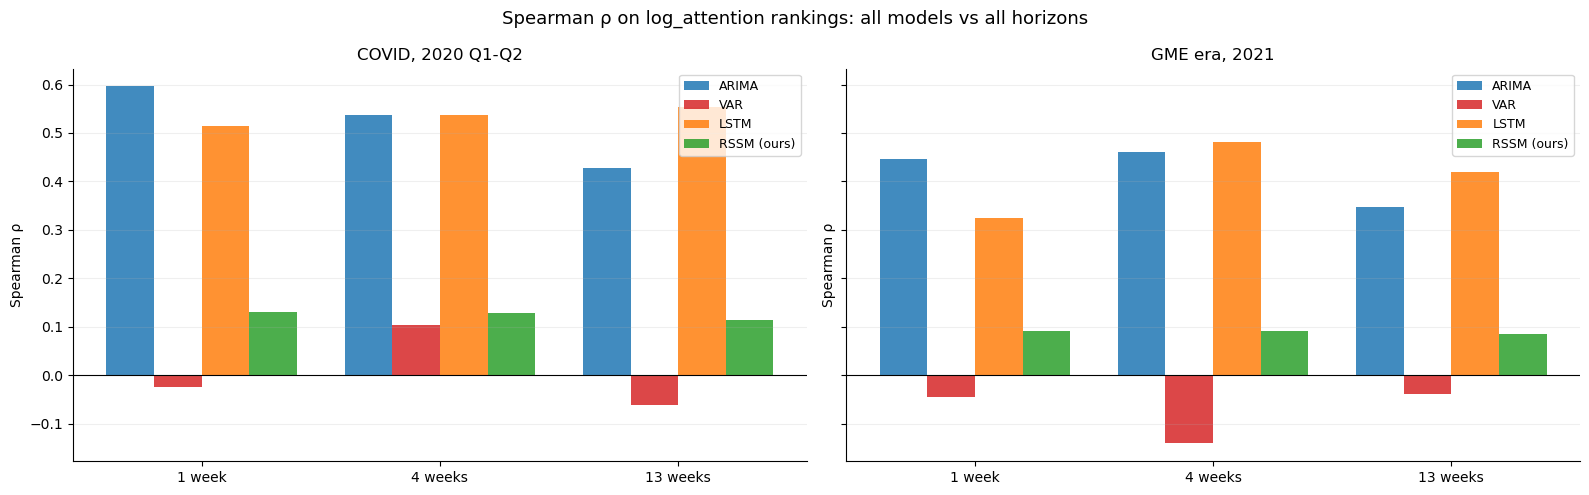

Saved → /Users/narayanipemmaraju/Documents/MSDS/Spring 2026/ML/Project/Repo/StockTwit_WM/outputs/eval/extended_eval/spearman_comparison_bar.png


In [17]:
# Bar chart comparing all models
if not MODEL_READY:
    print("SKIP")
else:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
    horizons  = ["1 week", "4 weeks", "13 weeks"]
    models    = ["ARIMA", "VAR", "LSTM", "RSSM (ours)"]
    colors    = ["#1f77b4", "#d62728", "#ff7f0e", "#2ca02c"]
    x         = np.arange(len(horizons))
    width     = 0.2

    for ax, (split_key, split_label) in zip(
        axes, [("test1", "COVID, 2020 Q1-Q2"), ("test2", "GME era, 2021")]
    ):
        sub = comparison_df[comparison_df["Split"] == split_label]
        for j, (model_name, color) in enumerate(zip(models, colors)):
            row = sub[sub["Model"] == model_name]
            if row.empty:
                continue
            vals = [float(row[h].iloc[0]) for h in ["1 week", "4 weeks", "13 weeks"]]
            ax.bar(x + j * width, vals, width, label=model_name, color=color, alpha=0.85)

        ax.axhline(0, color="black", lw=0.8)
        ax.set_xticks(x + width * 1.5)
        ax.set_xticklabels(horizons)
        ax.set_title(split_label)
        ax.set_ylabel("Spearman ρ")
        ax.legend(fontsize=9)
        ax.grid(axis="y", alpha=0.2)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    fig.suptitle("Spearman ρ on log_attention rankings: all models vs all horizons", fontsize=13)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "spearman_comparison_bar.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {OUT_DIR / 'spearman_comparison_bar.png'}")

In [18]:
kl_df = pd.read_csv(OUT_DIR / "kl_full_test_series.csv")
kl_df["week"] = pd.to_datetime(kl_df["week"])

# Define shock vs calm within each test period
shock_weeks = ["2020-02-20", "2020-03-09", "2020-03-23"]
gme_weeks   = ["2021-01-22", "2021-01-28", "2021-02-01"]

t1 = kl_df[kl_df["week"] <= "2020-06-30"].copy()
t2 = kl_df[kl_df["week"] >  "2020-06-30"].copy()

t1["type"] = t1["week"].apply(
    lambda w: "shock" if str(w.date()) in shock_weeks else "calm"
)
t2["type"] = t2["week"].apply(
    lambda w: "shock" if str(w.date()) in gme_weeks else "calm"
)

print("── Test1 (COVID): shock vs calm ──")
print(t1.groupby("type")["kl"].agg(["mean","std","count"]).round(3))

print("\n── Test2 (GME): shock vs calm ──")
print(t2.groupby("type")["kl"].agg(["mean","std","count"]).round(3))

── Test1 (COVID): shock vs calm ──
         mean    std  count
type                       
calm   54.587  1.964     24
shock  50.947  2.585      2

── Test2 (GME): shock vs calm ──
         mean    std  count
type                       
calm   53.177  1.672     38
shock  55.201    NaN      1


---
## Summary of Outputs

All files are written to `outputs/eval/extended_eval/`:

| File | Used for |
|---|---|
| `kl_full_test_series.csv` | KL value per test week |
| `kl_full_test_timeline.png` | Figure replacing Table 3 |
| `kl_event_summary.csv` | Updated Table 3 with ±4-week window z-scores |
| `residual_corr_test1.csv` | COVID residual correlation matrix |
| `residual_corr_test2.csv` | GME residual correlation matrix |
| `residual_corr_comparison.png` | Side-by-side heatmaps |
| `rssm_spearman.csv` | RSSM Spearman ρ by split and horizon |
| `full_spearman_comparison.csv` | Full Table 2 + RSSM row |
| `spearman_comparison_bar.png` | Bar chart of all models |
